D3 Metro — iterative vs one-shot pruning (+ best D2 combo prune+coreset)


Saving Metro_Interstate_Traffic_Volume.csv to Metro_Interstate_Traffic_Volume.csv
Input dim: 456

===== SEED 1 =====
  baseline (seed 1)
    epoch  1/20  loss 0.045703
    epoch  2/20  loss 0.023514
    epoch  3/20  loss 0.019145
    epoch  4/20  loss 0.017052
    epoch  5/20  loss 0.015870
    epoch  6/20  loss 0.015253
    epoch  7/20  loss 0.014043
    epoch  8/20  loss 0.013758
    epoch  9/20  loss 0.012461
    epoch 10/20  loss 0.011888
    epoch 11/20  loss 0.011199
    epoch 12/20  loss 0.010652
    epoch 13/20  loss 0.010229
    epoch 14/20  loss 0.009533
    epoch 15/20  loss 0.009139
    epoch 16/20  loss 0.008805
    epoch 17/20  loss 0.008390
    epoch 18/20  loss 0.008054
    epoch 19/20  loss 0.007655
    epoch 20/20  loss 0.007385
  one-shot fine-tune 80% (seed 1)
    epoch  1/20  loss 0.009120
    epoch  2/20  loss 0.007121
    epoch  3/20  loss 0.006684
    epoch  4/20  loss 0.006402
    epoch  5/20  loss 0.006083
    epoch  6/20  loss 0.005906
    epoch  7/20  loss 0

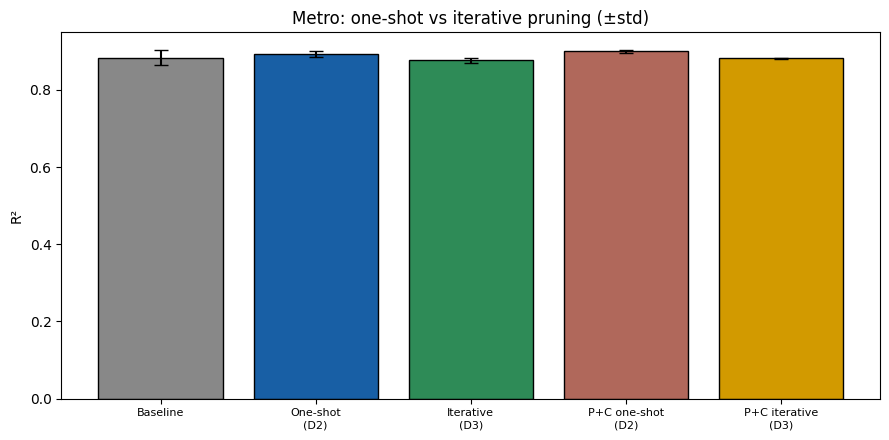

In [1]:
# ============================================================================
# D3 — IMPROVEMENT: ITERATIVE PRUNING vs ONE-SHOT PRUNING (D2) — METRO INTERSTATE
# Builds on the D2 pipeline (UNCHANGED architecture/preprocessing).
# Compares: Baseline | One-shot 80% (D2) | Iterative 80% (D3) |
#           Prune+Coreset one-shot (D2 best) | Prune+Coreset iterative (D3).
# Seeds [1, 7, 13], error bars. Coreset fraction = 100% (matches D2 Metro best).
# ============================================================================

# ---------------- imports ----------------
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import copy, io, torch, torch.nn as nn
import torch.nn.utils.prune as prune
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEEDS=[1,7,13]; EPOCHS=20
print("D3 Metro — iterative vs one-shot pruning (+ best D2 combo prune+coreset)")

# ---------------- B2: upload + cleaning (same as D1/D2) ----------------
from google.colab import files
uploaded=files.upload()
df=pd.read_csv(list(uploaded.keys())[0])
df['date_time']=pd.to_datetime(df['date_time'])
df=df.drop_duplicates(subset='date_time').sort_values('date_time').reset_index(drop=True)
df=df[df['temp']>0]; df=df[df['rain_1h']<1000]
df['is_holiday']=df['holiday'].notna().astype(int)
df['hour']=df['date_time'].dt.hour; df['dow']=df['date_time'].dt.dayofweek; df['month']=df['date_time'].dt.month
for col in ['temp','rain_1h']:
    q1,q3=df[col].quantile(0.25),df[col].quantile(0.75); iqr=q3-q1
    df=df[(df[col]>=q1-1.5*iqr)&(df[col]<=q3+1.5*iqr)]
df=df.reset_index(drop=True)
weather=pd.get_dummies(df['weather_main'],prefix='wm').astype(float)
numeric=df[['temp','rain_1h','snow_1h','clouds_all','is_holiday','hour','dow','month']].astype(float)
features=pd.concat([numeric,weather],axis=1); target=df['traffic_volume'].astype(float).values.reshape(-1,1)
sp=int(len(features)*0.8)
fsc=MinMaxScaler().fit(features.iloc[:sp]); tsc=MinMaxScaler().fit(target[:sp])
Xs=fsc.transform(features); ys=tsc.transform(target)
def mw(X,y,window=24):
    Xw,Yw=[],[]
    for i in range(len(X)-window): Xw.append(X[i:i+window].flatten()); Yw.append(y[i+window])
    return np.array(Xw,np.float32),np.array(Yw,np.float32)
X_all,Y_all=mw(Xs,ys); s2=int(len(X_all)*0.8)
X_train,Y_train=X_all[:s2],Y_all[:s2]; X_test,Y_test=X_all[s2:],Y_all[s2:]
vc=int(len(X_train)*0.9); X_tr,Y_tr=X_train[:vc],Y_train[:vc]
to_t=lambda a: torch.tensor(a,dtype=torch.float32); X_tr_t,Y_tr_t,X_te_t=to_t(X_tr),to_t(Y_tr),to_t(X_test)
IN_DIM=X_all.shape[1]; print("Input dim:",IN_DIM)

def evaluate(pred):
    yt=tsc.inverse_transform(Y_test).flatten(); yp=tsc.inverse_transform(pred).flatten(); mask=yt>1e-6
    return {"R2":r2_score(yt,yp),"MAE":mean_absolute_error(yt,yp),
            "RMSE":np.sqrt(mean_squared_error(yt,yp)),
            "MAPE":np.mean(np.abs((yt[mask]-yp[mask])/yt[mask]))*100}
def agg(runs):
    ks=runs[0].keys(); return {k:(float(np.mean([r[k] for r in runs])),float(np.std([r[k] for r in runs]))) for k in ks}
def fmt(s): return f"{s[0]:.4f} +/- {s[1]:.4f}"

class TrafficMLP(nn.Module):
    def __init__(self,in_dim=IN_DIM,out_dim=1):
        super().__init__(); self.net=nn.Sequential(nn.Linear(in_dim,128),nn.ReLU(),nn.Linear(128,64),nn.ReLU(),
                                                   nn.Linear(64,32),nn.ReLU(),nn.Linear(32,16),nn.ReLU(),nn.Linear(16,out_dim))
    def forward(self,x): return self.net(x)
def train_mlp(model,Xtr,Ytr,seed,epochs=EPOCHS,bs=64,lr=0.001,label=""):
    torch.manual_seed(seed); opt=torch.optim.Adam(model.parameters(),lr=lr); crit=nn.MSELoss(); n=len(Xtr)
    if label: print(f"  {label} (seed {seed})")
    for ep in range(epochs):
        model.train(); perm=torch.randperm(n); run=0.0
        for i in range(0,n,bs):
            idx=perm[i:i+bs]; opt.zero_grad(); loss=crit(model(Xtr[idx]),Ytr[idx]); loss.backward(); opt.step(); run+=loss.item()*len(idx)
        print(f"    epoch {ep+1:2d}/{epochs}  loss {run/n:.6f}")
    return model
def predict(m):
    m.eval()
    with torch.no_grad(): return m(X_te_t).numpy()
def lin_mods(m): return [x for x in m.modules() if isinstance(x,nn.Linear)]

def oneshot_prune(base,seed,target=0.8):
    m=copy.deepcopy(base); mods=lin_mods(m)
    prune.global_unstructured([(x,'weight') for x in mods],pruning_method=prune.L1Unstructured,amount=target)
    m=train_mlp(m,X_tr_t,Y_tr_t,seed,label=f"one-shot fine-tune {int(target*100)}%")
    for x in mods: prune.remove(x,'weight')
    return m
def iterative_prune(base,seed,steps=[0.2,0.4,0.6,0.8]):
    m=copy.deepcopy(base); mods=lin_mods(m); prev=0
    for tgt in steps:
        amt=tgt if prev==0 else (tgt-prev)/(1-prev)
        prune.global_unstructured([(x,'weight') for x in mods],pruning_method=prune.L1Unstructured,amount=amt)
        m=train_mlp(m,X_tr_t,Y_tr_t,seed,label=f"iterative step ->{int(tgt*100)}%"); prev=tgt
    for x in mods: prune.remove(x,'weight')
    return m

# D2 best combo for Metro = prune+coreset. Iterative version = coreset-train then iterative-prune.
def prune_coreset_oneshot(seed, frac=1.0, target=0.8):
    torch.manual_seed(seed); k=int(len(X_tr_t)*frac); idx=torch.randperm(len(X_tr_t))[:k]
    mc=train_mlp(TrafficMLP(),X_tr_t[idx],Y_tr_t[idx],seed,label="coreset train");
    return oneshot_prune(mc,seed,target)
def prune_coreset_iterative(seed, frac=1.0):
    torch.manual_seed(seed); k=int(len(X_tr_t)*frac); idx=torch.randperm(len(X_tr_t))[:k]
    mc=train_mlp(TrafficMLP(),X_tr_t[idx],Y_tr_t[idx],seed,label="coreset train")
    return iterative_prune(mc,seed)

base_runs,os_runs,it_runs,pc_os,pc_it = [],[],[],[],[]
for s in SEEDS:
    print(f"\n===== SEED {s} =====")
    torch.manual_seed(s); base=train_mlp(TrafficMLP(),X_tr_t,Y_tr_t,s,label="baseline")
    base_runs.append(evaluate(predict(base)))
    os_runs.append(evaluate(predict(oneshot_prune(base,s))))
    it_runs.append(evaluate(predict(iterative_prune(base,s))))
    pc_os.append(evaluate(predict(prune_coreset_oneshot(s))))     # D2 best combo
    pc_it.append(evaluate(predict(prune_coreset_iterative(s))))   # D3 improved combo
base_s,os_s,it_s,pcos_s,pcit_s = agg(base_runs),agg(os_runs),agg(it_runs),agg(pc_os),agg(pc_it)

print("\n=== METRO: D3 comparison (mean +/- std over seeds", SEEDS, ") ===")
print(f"  Baseline MLP                 R2 = {fmt(base_s['R2'])}")
print(f"  One-shot prune 80% (D2)      R2 = {fmt(os_s['R2'])}")
print(f"  Iterative prune 80% (D3)     R2 = {fmt(it_s['R2'])}")
print(f"  Prune+Coreset one-shot (D2)  R2 = {fmt(pcos_s['R2'])}")
print(f"  Prune+Coreset iterative (D3) R2 = {fmt(pcit_s['R2'])}")

labels=["Baseline","One-shot\n(D2)","Iterative\n(D3)","P+C one-shot\n(D2)","P+C iterative\n(D3)"]
means=[base_s['R2'][0],os_s['R2'][0],it_s['R2'][0],pcos_s['R2'][0],pcit_s['R2'][0]]
stds=[base_s['R2'][1],os_s['R2'][1],it_s['R2'][1],pcos_s['R2'][1],pcit_s['R2'][1]]
plt.figure(figsize=(9,4.5))
plt.bar(range(5),means,yerr=stds,capsize=5,color=["#888","#185FA5","#2e8b57","#b0685b","#d29a00"],edgecolor="black")
plt.xticks(range(5),labels,fontsize=8); plt.ylabel("R²")
plt.title("Metro: one-shot vs iterative pruning (±std)")
plt.tight_layout(); plt.show()